# LexCausa — Statistical Analysis of the Multi-DoE Campaign

Full statistical suite for the full-factorial design
**Reasoner (2) × Counter (2) × Reasoning paradigm (3) × Claims (12) × Replicates (5)**.

Tests, per research question (as agreed with the advisor):

| RQ | Factor | Levels | Test |
|----|--------|--------|------|
| RQ1 | Model class | 2 | **Wilcoxon** signed-rank (paired by claim) |
| RQ2 | Reasoner×Counter pairing | 2×2 | ANOVA **interaction** term |
| RQ3 | Reasoning paradigm | 3 | **Friedman** + **Dunn** post-hoc (**Holm**) + win/tie/loss |

Beyond the separate RQs, Section 2 fits a **full factorial ANOVA with all interactions**
(model × model × paradigm) and Section 7 does **data slicing** (per-domain, class×paradigm),
to read cross-factor effects directly. The notebook is robust to the current 2-paradigm
(480-run) data and to the full 3-paradigm (720-run) data: Friedman activates once the
paradigm has ≥3 levels.

In [1]:
# --- Setup & data loading ---------------------------------------------------
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np, pandas as pd
import scipy.stats as st
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
import scikit_posthocs as sp

# Point this at a merged metrics.csv OR a directory of shard dirs to concatenate.
# RUN_DIR = Path("../runs/or_doe480_merged")         # 480 (2 paradigms)
RUN_DIR = Path("../runs/or_doe720_merged")           # full 720 (3 paradigms)
FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)

def load_metrics(path: Path) -> pd.DataFrame:
    p = Path(path)
    if (p / "metrics.csv").exists():
        return pd.read_csv(p / "metrics.csv")
    # else: concatenate every */metrics.csv beneath it (shard dirs)
    frames = [pd.read_csv(f) for f in sorted(p.glob("*/metrics.csv"))]
    if not frames:
        raise FileNotFoundError(f"No metrics.csv under {p}")
    return pd.concat(frames, ignore_index=True)

df = load_metrics(RUN_DIR)
df = df[df.get("status", "completed").astype(str).str.lower().ne("failed")].copy()

REASONING = {"deepseek_r1", "gpt_oss_120b"}
def cls(m): return "reasoning" if m in REASONING else "instruction_tuned"
df["reasoner_class"] = df["reasoner_model"].map(cls)
df["counter_class"]  = df["counter_model"].map(cls)

# The raw `domain` column is misaligned for the boundary claims (C3/P3/M3 get the
# next domain). The claim_id prefix is authoritative, so derive domain from it.
_DOM = {"C": "CIVILE", "P": "PENALE", "M": "MISTO", "A": "AMMINISTRATIVO"}
df["domain"] = (df["claim_id"].astype(str).str[0].map(_DOM)
                .fillna(df.get("domain")))

def _truthy(x, default=False):
    if pd.isna(x): return default
    return str(x).strip().lower() in {"true","1","yes","on","t"}
def _para(r):
    if _truthy(r.get("single_call_reasoner")) or _truthy(r.get("single_call_counter")):
        return "single_call"
    return "plan_then_execute" if _truthy(r.get("planning_reasoner"), True) else "stepwise"
if "paradigm" not in df.columns:
    df["paradigm"] = df.apply(_para, axis=1)
else:  # backfill rows with a missing/NaN paradigm (merged old on/off + single-call)
    _m = df["paradigm"].isna()
    if _m.any():
        df.loc[_m, "paradigm"] = df[_m].apply(_para, axis=1)

PARADIGM_ORDER = ["plan_then_execute", "stepwise", "single_call"]
df["paradigm"] = pd.Categorical(df["paradigm"],
    [p for p in PARADIGM_ORDER if p in df["paradigm"].unique()], ordered=True)

RESPONSES = [c for c in
    ["aqa_plausibility","aqa_cogency","aqa_norm_support","aqa_semantics",
     "citation_accuracy","total_tokens"] if c in df.columns]
PRETTY = {"aqa_plausibility":"AQA net plausibility","aqa_cogency":"Cogency",
          "aqa_norm_support":"NormSupport","aqa_semantics":"Semantics",
          "citation_accuracy":"Fidelity","total_tokens":"Token cost"}
PRETTY_MODEL = {"gpt_oss_120b":"GPT-OSS-120B", "llama_3_3_70b":"Llama-3.3-70B",
                "deepseek_r1":"DeepSeek-R1", "qwen_25_72b":"Qwen-2.5-72B"}

n_paradigms = df["paradigm"].nunique()
print(f"Loaded {len(df)} runs | claims={df['claim_id'].nunique()} | "
      f"paradigms={list(df['paradigm'].cat.categories)} ({n_paradigms} levels)")
df.head(3)

Loaded 720 runs | claims=12 | paradigms=['plan_then_execute', 'stepwise', 'single_call'] (3 levels)


,claim_id,domain,reasoner_model,counter_model,planning_reasoner,planning_counter,causality_enabled,replicate,aqa_verdict,aqa_plausibility,...,status,duration_sec,started_at,completed_at,single_call_reasoner,single_call_counter,paradigm,error,reasoner_class,counter_class
0,C1,CIVILE,gpt_oss_120b,gpt_oss_120b,True,True,True,0,uncertain,-0.086172,...,completed,252.840490,2026-07-04T21:08:05.896591,2026-07-04T21:12:18.737081,NaN,NaN,plan_then_execute,NaN,reasoning,reasoning
1,C1,CIVILE,gpt_oss_120b,gpt_oss_120b,True,True,True,4,uncertain,0.084427,...,completed,212.995217,2026-07-04T21:12:18.763464,2026-07-04T21:15:51.758681,NaN,NaN,plan_then_execute,NaN,reasoning,reasoning
2,C1,CIVILE,gpt_oss_120b,gpt_oss_120b,False,False,True,3,uncertain,0.071968,...,completed,271.575278,2026-07-04T21:15:51.769914,2026-07-04T21:20:23.345192,NaN,NaN,stepwise,NaN,reasoning,reasoning


## 1. Descriptive overview

,mean,std,min,max
AQA net plausibility,0.1876,0.2788,-0.5424,0.8069
Cogency,0.6317,0.1052,0.3808,0.8619
NormSupport,0.9346,0.0624,0.5581,1.0000
Semantics,0.7518,0.1156,0.0958,0.9890
Fidelity,0.9624,0.1872,0.0000,1.0000
Token cost,10803.2764,5700.2932,1665.0000,29550.0000


Verdict distribution: {'uncertain': 0.5125, 'plausible': 0.4306, 'implausible': 0.0569}
Abstention rate: 0.1


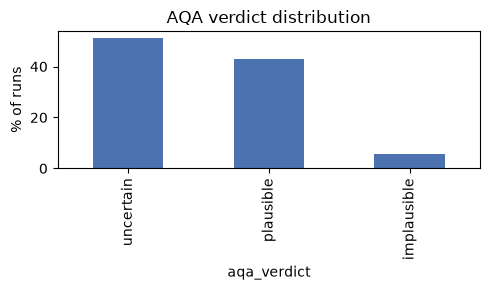

In [2]:
# Grand descriptives
desc = df[RESPONSES].agg(["mean","std","min","max"]).T
desc.index = [PRETTY[i] for i in desc.index]
display(desc.round(4))

# Verdict distribution & abstention
if "aqa_verdict" in df.columns:
    vc = df["aqa_verdict"].value_counts(normalize=True).round(4)
    print("Verdict distribution:", vc.to_dict())
if "counter_abstained" in df.columns:
    print("Abstention rate:", round(df["counter_abstained"].astype(bool).mean(), 4))

# Verdict bar plot
if "aqa_verdict" in df.columns:
    fig, ax = plt.subplots(figsize=(5,3))
    (df["aqa_verdict"].value_counts(normalize=True)*100).plot.bar(ax=ax, color="#4C72B0")
    ax.set_ylabel("% of runs"); ax.set_title("AQA verdict distribution")
    plt.tight_layout(); plt.savefig(FIG_DIR/"verdict_distribution.pdf"); plt.show()

## 2. Full factorial ANOVA with interactions

Beyond the marginal RQs, we fit the complete model
`response ~ C(reasoner) * C(counter) * C(paradigm)` (Type-II sums of squares),
which yields **every main effect, every two-way interaction, and the three-way
interaction** in one decomposition. `eta_sq = SS_effect / SS_total` is the practical
importance; the `F` test gives significance. Levene checks homoscedasticity.

In [3]:
def factorial_anova(response: str) -> pd.DataFrame:
    d = df[["reasoner_model","counter_model","paradigm",response]].dropna().copy()
    d.columns = ["rmodel","cmodel","para","y"]  # avoid the name 'C' (patsy fn)
    terms = "C(rmodel)*C(cmodel)" if d["para"].nunique() < 2 else "C(rmodel)*C(cmodel)*C(para)"
    model = smf.ols(f"y ~ {terms}", data=d).fit()
    aov = anova_lm(model, typ=2)
    sst = aov["sum_sq"].sum()
    aov["eta_sq"] = aov["sum_sq"] / sst
    return aov[["sum_sq","df","F","PR(>F)","eta_sq"]].rename(columns={"PR(>F)":"p"})

for r in ["aqa_plausibility","total_tokens"]:
    print(f"\n===== {PRETTY[r]} =====")
    display(factorial_anova(r).round({"sum_sq":4,"F":2,"p":5,"eta_sq":4}))

# Compact eta^2 table across responses for every effect
rows = {}
for r in RESPONSES:
    a = factorial_anova(r)
    rows[PRETTY[r]] = a["eta_sq"]
eta_tab = pd.DataFrame(rows)
eta_tab = eta_tab[eta_tab.index != "Residual"]
print("\nEffect sizes (eta^2) across responses:")
display(eta_tab.round(4))


===== AQA net plausibility =====


,sum_sq,df,F,p,eta_sq
C(rmodel),2.7791,1.0,43.97,0.00000,0.0497
C(cmodel),3.2063,1.0,50.73,0.00000,0.0574
C(para),3.2246,2.0,25.51,0.00000,0.0577
C(rmodel):C(cmodel),0.0071,1.0,0.11,0.73733,0.0001
C(rmodel):C(para),1.4658,2.0,11.60,0.00001,0.0262
C(cmodel):C(para),0.2080,2.0,1.65,0.19367,0.0037
C(rmodel):C(cmodel):C(para),0.2580,2.0,2.04,0.13066,0.0046
Residual,44.7481,708.0,NaN,NaN,0.8005



===== Token cost =====


,sum_sq,df,F,p,eta_sq
C(rmodel),2.643632e+09,1.0,192.87,0.00000,0.1132
C(cmodel),1.403351e+09,1.0,102.38,0.00000,0.0601
C(para),8.392101e+09,2.0,306.13,0.00000,0.3592
C(rmodel):C(cmodel),7.526489e+07,1.0,5.49,0.01939,0.0032
C(rmodel):C(para),4.659468e+08,2.0,17.00,0.00000,0.0199
C(cmodel):C(para),6.588722e+08,2.0,24.03,0.00000,0.0282
C(rmodel):C(cmodel):C(para),1.900187e+07,2.0,0.69,0.50034,0.0008
Residual,9.704544e+09,708.0,NaN,NaN,0.4154



Effect sizes (eta^2) across responses:


,AQA net plausibility,Cogency,NormSupport,Semantics,Fidelity,Token cost
C(rmodel),0.0497,0.1924,0.0253,0.2479,0.0000,0.1132
C(cmodel),0.0574,0.0000,0.0018,0.0004,0.0207,0.0601
C(para),0.0577,0.3533,0.0090,0.0505,0.0040,0.3592
C(rmodel):C(cmodel),0.0001,0.0000,0.0000,0.0000,0.0003,0.0032
C(rmodel):C(para),0.0262,0.0222,0.0024,0.1255,0.0025,0.0199
C(cmodel):C(para),0.0037,0.0001,0.0019,0.0007,0.0049,0.0282
C(rmodel):C(cmodel):C(para),0.0046,0.0001,0.0004,0.0002,0.0041,0.0008


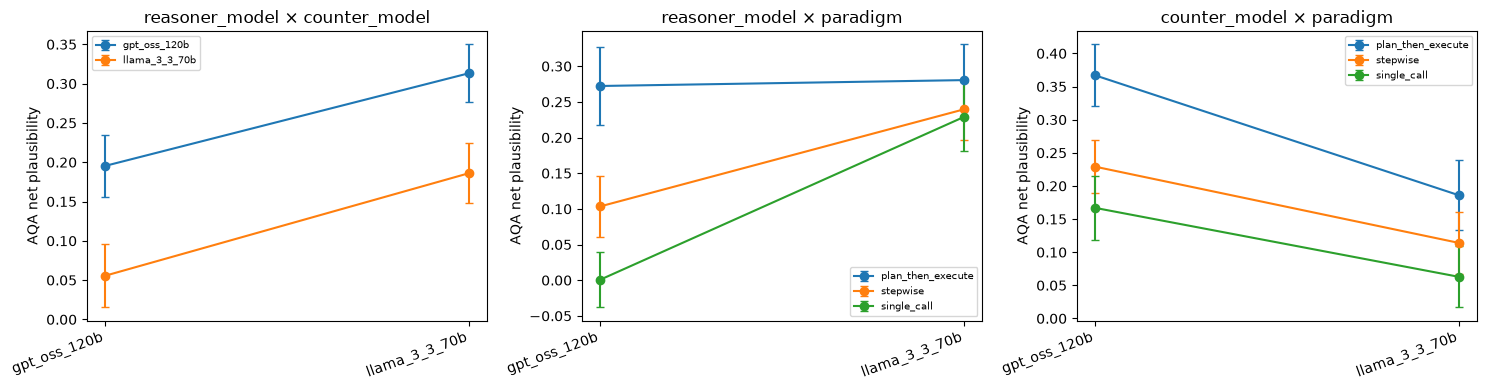

In [4]:
# Interaction plots on AQA net plausibility (means +/- 95% CI)
def cell_mean_ci(sub, by):
    g = sub.groupby(by)["aqa_plausibility"]
    m = g.mean(); se = g.sem(); return m, 1.96*se

pairs = [("reasoner_model","counter_model"),
         ("reasoner_model","paradigm"),
         ("counter_model","paradigm")]
pairs = [(a,b) for a,b in pairs if df[b].nunique() > 1]
fig, axes = plt.subplots(1, len(pairs), figsize=(5*len(pairs),4), squeeze=False)
for ax,(f1,f2) in zip(axes[0], pairs):
    for lv in df[f2].cat.categories if hasattr(df[f2],"cat") else df[f2].unique():
        sub = df[df[f2]==lv]
        m, ci = cell_mean_ci(sub, f1)
        ax.errorbar(range(len(m)), m.values, yerr=ci.values, marker="o", capsize=3, label=str(lv))
        ax.set_xticks(range(len(m))); ax.set_xticklabels(m.index, rotation=20, ha="right")
    ax.set_title(f"{f1} × {f2}"); ax.set_ylabel("AQA net plausibility")
    ax.legend(fontsize=7)
plt.tight_layout(); plt.savefig(FIG_DIR/"interaction_plots.pdf"); plt.show()

## 3. RQ1 — Model class (Wilcoxon signed-rank, paired by claim)

,response,reasoning,instruction_tuned,W,p,better,n_claims
0,AQA net plausibility,0.1254,0.2497,0.0,0.0005,instruction_tuned,12
1,Cogency,0.5856,0.6778,0.0,0.0005,instruction_tuned,12
2,NormSupport,0.9246,0.9445,14.0,0.0522,instruction_tuned,12
3,Semantics,0.6943,0.8093,0.0,0.0005,instruction_tuned,12
4,Fidelity,0.9621,0.9627,19.0,0.7109,instruction_tuned,12
5,Token cost,12719.4472,8887.1056,0.0,0.0005,reasoning,12


Per-class  mean ± std:


reasoner_class,instruction_tuned,reasoning
AQA net plausibility,0.2497 ± 0.2637,0.1254 ± 0.2801
Cogency,0.6778 ± 0.1046,0.5856 ± 0.0834
NormSupport,0.9445 ± 0.0645,0.9246 ± 0.0587
Semantics,0.8093 ± 0.092,0.6943 ± 0.1081
Fidelity,0.9627 ± 0.1874,0.9621 ± 0.1873
Token cost,8887.1056 ± 4653.5646,12719.4472 ± 6004.8028


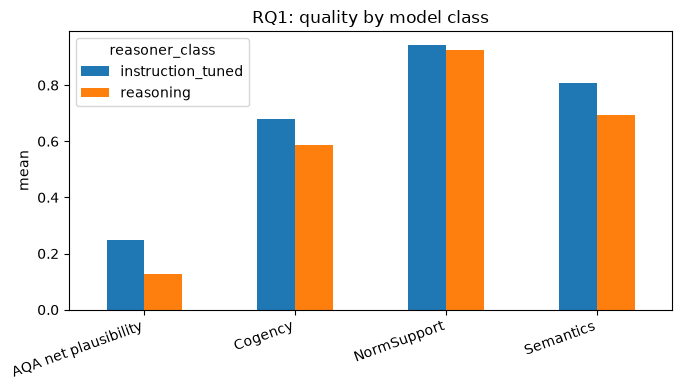

In [5]:
# Aggregate to one value per claim per class, then paired Wilcoxon.
def rq1_wilcoxon(response):
    piv = (df.groupby(["claim_id","reasoner_class"])[response].mean()
             .unstack("reasoner_class"))
    piv = piv.dropna()
    if {"reasoning","instruction_tuned"} - set(piv.columns):
        return None
    stat, p = st.wilcoxon(piv["reasoning"], piv["instruction_tuned"])
    better = ("reasoning" if piv["reasoning"].mean() > piv["instruction_tuned"].mean()
              else "instruction_tuned")
    return dict(response=PRETTY[response],
                reasoning=piv["reasoning"].mean(),
                instruction_tuned=piv["instruction_tuned"].mean(),
                W=stat, p=p, better=better, n_claims=len(piv))

rq1 = pd.DataFrame([r for r in (rq1_wilcoxon(x) for x in RESPONSES) if r])
display(rq1.round(4))

# Per-class mean +/- std across every response
cm_m = df.groupby("reasoner_class")[RESPONSES].mean().round(4)
cm_s = df.groupby("reasoner_class")[RESPONSES].std().round(4)
cm = (cm_m.astype(str) + "  ± " + cm_s.astype(str))
cm.columns = [PRETTY[c] for c in cm.columns]
print("Per-class  mean ± std:")
display(cm.T)

# Per-class means bar plot for the quality responses
qual = ["aqa_plausibility","aqa_cogency","aqa_norm_support","aqa_semantics"]
means = df.groupby("reasoner_class")[qual].mean().T
means.index = [PRETTY[i] for i in means.index]
means.plot.bar(figsize=(7,4)); plt.ylabel("mean"); plt.title("RQ1: quality by model class")
plt.xticks(rotation=20, ha="right"); plt.tight_layout()
plt.savefig(FIG_DIR/"rq1_class_quality.pdf"); plt.show()

## 4. RQ2 — Dialectical pairing (interaction term + grid)

Reasoner×Counter interaction on AQA: {'F': 0.11258, 'p': 0.73733, 'eta_sq': 0.00013}


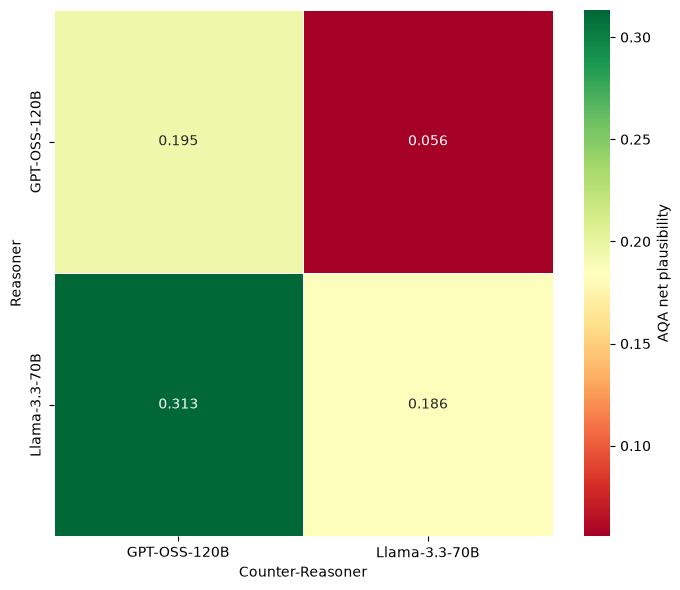

In [6]:
# Interaction significance on AQA
a = factorial_anova("aqa_plausibility")
_term = "C(rmodel):C(cmodel)"
print("Reasoner×Counter interaction on AQA:",
      a.loc[_term, ["F","p","eta_sq"]].round(5).to_dict()
      if _term in a.index else "n/a")

# 2×2 grid heatmap, in the transferability-matrix style (seaborn RdYlGn)
grid = (df.pivot_table(index="reasoner_model", columns="counter_model",
                       values="aqa_plausibility", aggfunc="mean")
          .rename(index=PRETTY_MODEL, columns=PRETTY_MODEL))
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(grid, cmap="RdYlGn", annot=True, fmt=".3f",
            linewidths=0.5, linecolor="white",
            vmin=float(grid.values.min()), vmax=float(grid.values.max()),
            cbar_kws={"label": "AQA net plausibility"}, ax=ax)
ax.set_xlabel("Counter-Reasoner"); ax.set_ylabel("Reasoner")
plt.tight_layout()
plt.savefig(FIG_DIR/"rq2_grid.pdf", bbox_inches="tight"); plt.show()

## 5. RQ3 — Reasoning paradigm (Friedman + Dunn/Holm + win/tie/loss)

Friedman needs ≥3 related groups. With the current 2-paradigm data it does **not**
apply (only Plan-then-Execute vs step-wise), so the cell falls back to a paired
Wilcoxon and notes it. Once the single-call arm is merged (3 levels), the full
Friedman + Dunn (Holm) + win/tie/loss runs automatically.


=== AQA net plausibility — Friedman chi2=9.500, p=0.00865 (n=12 claims) ===


,plan_then_execute,single_call,stepwise
plan_then_execute,1.0000,0.0140,0.1558
single_call,0.0140,1.0000,0.2866
stepwise,0.1558,0.2866,1.0000


Win/tie/loss (row vs col):


,plan_then_execute,stepwise,single_call
plan_then_execute,—,tie,win
stepwise,tie,—,tie
single_call,loss,tie,—



=== Fidelity — Friedman chi2=5.241, p=0.07275 (n=12 claims) ===


...

,plan_then_execute,stepwise,single_call
plan_then_execute,—,tie,win
stepwise,tie,—,win
single_call,loss,loss,—


Per-paradigm  mean ± std:


,AQA net plausibility,Cogency,NormSupport,Semantics,Fidelity,Token cost
paradigm,,,,,,
plan_then_execute,0.2764 ± 0.2918,0.6513 ± 0.0397,0.9363 ± 0.0499,0.7213 ± 0.0596,0.9535 ± 0.2097,12091.275 ± 4962.741
stepwise,0.1715 ± 0.25,0.6965 ± 0.0656,0.9408 ± 0.0702,0.7848 ± 0.0767,0.9792 ± 0.1431,14189.0833 ± 5102.0607
single_call,0.1148 ± 0.2698,0.5473 ± 0.1251,0.9266 ± 0.0648,0.7493 ± 0.1695,0.9546 ± 0.2014,6129.4708 ± 3461.0294



Decomposition (net plausibility = pro - contra):


,aqa_pro,aqa_contra,aqa_plausibility,aqa_attack_coverage,counter_abstained
paradigm,,,,,
plan_then_execute,0.6309,0.3545,0.2764,0.2778,0.1875
stepwise,0.5429,0.3714,0.1715,0.4265,0.0625
single_call,0.3643,0.2495,0.1148,0.4852,0.0500


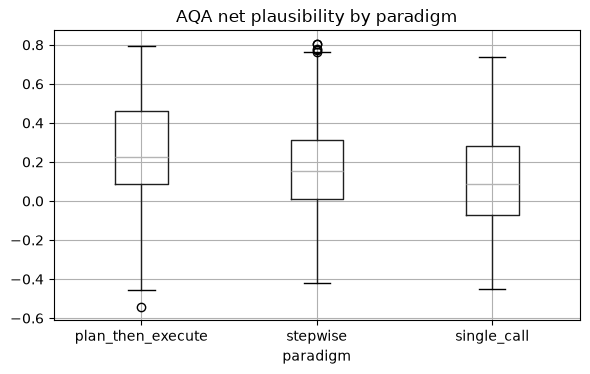

In [7]:
paradigms = list(df["paradigm"].cat.categories)
def per_claim_by_paradigm(response):
    return (df.groupby(["claim_id","paradigm"])[response].mean()
              .unstack("paradigm").dropna())

if len(paradigms) >= 3:
    for response in ["aqa_plausibility","citation_accuracy","total_tokens"]:
        piv = per_claim_by_paradigm(response)
        chi, p = st.friedmanchisquare(*[piv[c] for c in paradigms])
        print(f"\n=== {PRETTY[response]} — Friedman chi2={chi:.3f}, p={p:.5f} "
              f"(n={len(piv)} claims) ===")
        long = piv.reset_index().melt(id_vars="claim_id", var_name="paradigm", value_name="y")
        dunn = sp.posthoc_dunn(long, val_col="y", group_col="paradigm", p_adjust="holm")
        display(dunn.round(4))
        # Win/tie/loss on medians + Dunn significance (alpha=0.05)
        wtl = pd.DataFrame("tie", index=paradigms, columns=paradigms)
        med = piv.median()
        for a_ in paradigms:
            for b_ in paradigms:
                if a_==b_: wtl.loc[a_,b_]="—"; continue
                if dunn.loc[a_,b_] < 0.05:
                    wtl.loc[a_,b_] = "win" if med[a_] > med[b_] else "loss"
        print("Win/tie/loss (row vs col):"); display(wtl)
else:
    print("Only", len(paradigms), "paradigm level(s):", paradigms)
    print("Friedman not applicable yet — falling back to paired Wilcoxon (plan vs step-wise).")
    piv = per_claim_by_paradigm("aqa_plausibility")
    if piv.shape[1] == 2:
        c1, c2 = piv.columns
        stat, p = st.wilcoxon(piv[c1], piv[c2])
        print(f"Wilcoxon {c1} vs {c2} on AQA: W={stat}, p={p:.5f}, "
              f"means {piv[c1].mean():.4f} vs {piv[c2].mean():.4f}")

# Per-paradigm mean +/- std + box plot for AQA
pm_m = df.groupby("paradigm")[RESPONSES].mean().round(4)
pm_s = df.groupby("paradigm")[RESPONSES].std().round(4)
pm = pm_m.astype(str) + "  ± " + pm_s.astype(str)
pm.columns = [PRETTY[c] for c in pm.columns]
print("Per-paradigm  mean ± std:")
display(pm)
# also the pro/contra decomposition that explains net plausibility
if {"aqa_pro","aqa_contra"}.issubset(df.columns):
    dec = df.groupby("paradigm")[["aqa_pro","aqa_contra","aqa_plausibility",
                                  "aqa_attack_coverage","counter_abstained"]].mean().round(4)
    print("\nDecomposition (net plausibility = pro - contra):")
    display(dec)
fig, ax = plt.subplots(figsize=(6,4))
df.boxplot(column="aqa_plausibility", by="paradigm", ax=ax)
ax.set_title("AQA net plausibility by paradigm"); plt.suptitle("")
plt.tight_layout(); plt.savefig(FIG_DIR/"rq3_paradigm_box.pdf"); plt.show()

## 6. Efficiency and cost–quality trade-off

,tokens_mean,aqa_mean,tokens_per_quality_point
reasoner_class,,,
instruction_tuned,8887.11,0.25,35548.0
reasoning,12719.45,0.13,97842.0


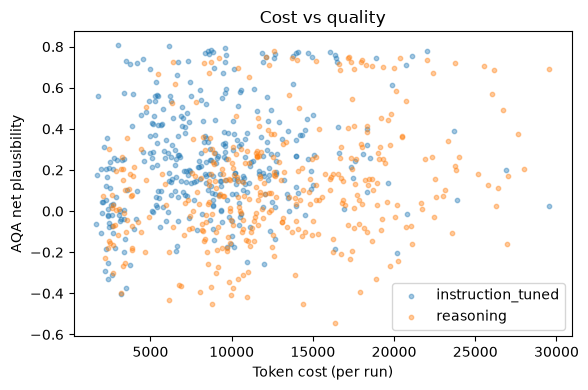

In [8]:
cost = df.groupby("reasoner_class").agg(
    tokens_mean=("total_tokens","mean"),
    aqa_mean=("aqa_plausibility","mean")).round(2)
cost["tokens_per_quality_point"] = (cost["tokens_mean"]/cost["aqa_mean"]).round(0)
display(cost)

fig, ax = plt.subplots(figsize=(6,4))
for k, sub in df.groupby("reasoner_class"):
    ax.scatter(sub["total_tokens"], sub["aqa_plausibility"], s=10, alpha=0.4, label=k)
ax.set_xlabel("Token cost (per run)"); ax.set_ylabel("AQA net plausibility")
ax.set_title("Cost vs quality"); ax.legend()
plt.tight_layout(); plt.savefig(FIG_DIR/"cost_quality.pdf"); plt.show()

## 7. Data slicing (cross-factor breakdowns)

In [9]:
# AQA by domain × paradigm and by class × paradigm
for idx in ["domain","reasoner_class"]:
    piv = df.pivot_table(index=idx, columns="paradigm",
                         values="aqa_plausibility", aggfunc="mean")
    print(f"\nAQA net plausibility — {idx} × paradigm")
    display(piv.round(4))


AQA net plausibility — domain × paradigm


paradigm,plan_then_execute,stepwise,single_call
domain,,,
AMMINISTRATIVO,0.3463,0.0608,0.0011
CIVILE,0.2001,0.1272,0.0992
MISTO,0.2997,0.2588,0.1309
PENALE,0.2594,0.2392,0.2282



AQA net plausibility — reasoner_class × paradigm


paradigm,plan_then_execute,stepwise,single_call
reasoner_class,,,
instruction_tuned,0.2805,0.2396,0.2290
reasoning,0.2722,0.1034,0.0007


## 8. Bootstrap CI for citation fidelity (proportion)

In [10]:
def boot_ci(x, B=2000, seed=42):
    rng = np.random.default_rng(seed)
    x = np.asarray(x, float)
    means = [rng.choice(x, size=len(x), replace=True).mean() for _ in range(B)]
    return np.mean(x), np.percentile(means, 2.5), np.percentile(means, 97.5)

if "citation_accuracy" in df.columns:
    m, lo, hi = boot_ci(df["citation_accuracy"])
    print(f"Fidelity overall: {m:.4f}  95% CI [{lo:.4f}, {hi:.4f}]")
    for k, sub in df.groupby("reasoner_class"):
        m, lo, hi = boot_ci(sub["citation_accuracy"])
        print(f"  {k:18s}: {m:.4f}  CI [{lo:.4f}, {hi:.4f}]")

Fidelity overall: 0.9624  95% CI [0.9488, 0.9759]
  instruction_tuned : 0.9627  CI [0.9428, 0.9817]
  reasoning         : 0.9621  CI [0.9424, 0.9797]


---
All figures are written to `figures/`. To analyze the full 720-run design, set
`RUN_DIR` to the merged directory once the single-call shards are combined; the
paradigm factor then has 3 levels and Section 5 runs the full Friedman/Dunn suite.